<a href="https://www.kaggle.com/code/marouanemourad/masked-face-super-resolution?scriptVersionId=321875343" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import tensorflow as tf
import os
import glob
from tensorflow.keras import layers, Model

import keras 
# from keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import re
from keras.preprocessing.image import img_to_array

2026-05-30 16:21:46.274307: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780158106.454736      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780158106.512543      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780158106.939620      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780158106.939660      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780158106.939663      23 computation_placer.cc:177] computation placer alr

##  env check

In [4]:
# List all physical GPU devices detected by TensorFlow
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
print(gpus)


# Verify if TensorFlow was built with CUDA support
print("Built with CUDA:", tf.test.is_built_with_cuda())

Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


adabt to speed up with tesla t4


In [5]:
# tf.keras.mixed_precision.set_global_policy('mixed_float16')

#  Step 1: Data Loading and Pairing Pipeline

In [6]:
# Source path of  dataset in Kaggle Input
KAGGLE_INPUT_DATA_PATH = "/kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/"

unmasked_dir = "/kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/without_mask/"
masked_dir = "/kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/with_mask/"



In [7]:
# import os

# def count_files(directory_path):
#     total_files = 0
#     png_count = 0

#     # Check if the directory exists first to avoid errors
#     if not os.path.exists(directory_path):
#         print(f"Error: The directory '{directory_path}' does not exist.")
#         return

#     # Loop through every item in the folder
#     for item in os.listdir(directory_path):
#         # Create the full path to check if it's a file (and not a sub-folder)
#         full_path = os.path.join(directory_path, item)
        
#         if os.path.isfile(full_path):
#             total_files += 1
            
#             # Check if the file ends with .png (using .lower() to catch .PNG as well)
#             if item.lower().endswith('.png'):
#                 png_count += 1

#     # Print the results
#     print(f"Directory analyzed: {directory_path}")
#     print(f"Total files: {total_files}")
#     print(f"Total .png images: {png_count}")

# # ------
# folder_to_check = '.' 
# count_files(masked_dir)
# count_files(unmasked_dir)

#result bellow aithout need to run the script every time:
print('''
Directory analyzed: /kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/with_mask
Total files: 10000
Total .png images: 10000

Directory analyzed: /kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/without_mask
Total files: 10000
Total .png images: 10000
''')


Directory analyzed: /kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/with_mask
Total files: 10000
Total .png images: 10000

Directory analyzed: /kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/without_mask
Total files: 10000
Total .png images: 10000



In [8]:


IMG_WIDTH = 256
IMG_HEIGHT = 256
BATCH_SIZE = 16

# def load_image_pair(masked_path):
#     # Extract the seed number from the masked image path (e.g., 'seed0001.png')
#     filename = tf.strings.split(masked_path, '/')[-1]
#     seed_part = tf.strings.split(filename, '.')[0] # gets 'seed0001'
    
#     # Construct the path for the corresponding unmasked image
#     # the string matching the exact naming convention of the dataset
#     unmasked_filename = tf.strings.join(['with-mask-default-mask-', seed_part, '.png'])
#     unmasked_path = tf.strings.join([unmasked_dir, unmasked_filename])
    
#     # Read and decode images
#     masked = tf.io.read_file(masked_path)
#     masked = tf.image.decode_png(masked, channels=3)
    
#     unmasked = tf.io.read_file(unmasked_path)
#     unmasked = tf.image.decode_png(unmasked, channels=3)
    
#     # Resize and normalize to [-1, 1] (Standard for GANs)
#     masked = tf.cast(tf.image.resize(masked, [IMG_HEIGHT, IMG_WIDTH]), tf.float32)
#     masked = (masked / 127.5) - 1
    
#     unmasked = tf.cast(tf.image.resize(unmasked, [IMG_HEIGHT, IMG_WIDTH]), tf.float32)
#     unmasked = (unmasked / 127.5) - 1
    
#     return masked, unmasked

def load_image_pair(masked_path):
    # Extract the full filename from the masked image path
    filename = tf.strings.split(masked_path, '/')[-1]
    
    # Remove the prefix to get the raw seed filename (e.g., turns 'with-mask-default-mask-seed0000.png' into 'seed0000.png')
    unmasked_filename = tf.strings.regex_replace(filename, 'with-mask-default-mask-', '')
    
    # Construct the correct path for the unmasked image
    unmasked_path = tf.strings.join([unmasked_dir, unmasked_filename])
    
    # Read and decode images
    masked = tf.io.read_file(masked_path)
    masked = tf.image.decode_png(masked, channels=3)
    
    unmasked = tf.io.read_file(unmasked_path)
    unmasked = tf.image.decode_png(unmasked, channels=3)
    
    # Resize and normalize to [-1, 1]
    masked = tf.cast(tf.image.resize(masked, [IMG_HEIGHT, IMG_WIDTH]), tf.float32)
    masked = (masked / 127.5) - 1
    
    unmasked = tf.cast(tf.image.resize(unmasked, [IMG_HEIGHT, IMG_WIDTH]), tf.float32)
    unmasked = (unmasked / 127.5) - 1
    
    return masked, unmasked

# # Create dataset - simple version
# masked_files = tf.data.Dataset.list_files(masked_dir + '*.png', shuffle=False)


# Create dataset
# Use os.path.join to safely combine the directory path and the wildcard
file_pattern = os.path.join(masked_dir, '*.png')
# Create dataset using the safe file pattern
masked_files = tf.data.Dataset.list_files(file_pattern, shuffle=False)



# Get total number of files to calculate split sizes
image_paths = tf.io.gfile.glob(file_pattern)
dataset_size = len(image_paths)

train_size = int(dataset_size * 0.8)
test_size = dataset_size - train_size

print(f"Total images: {dataset_size} | Training on: {train_size} | Testing on: {test_size}")

# Create dataset of file paths and shuffle BEFORE splitting
dataset = tf.data.Dataset.list_files(file_pattern, shuffle=False)
dataset = dataset.shuffle(dataset_size, seed=42) # Fixed seed ensures the split is consistent

# Split into train and test
train_files = dataset.take(train_size)
test_files = dataset.skip(train_size)

# Apply mapping, batching, and prefetching separately
train_ds = train_files.map(load_image_pair, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(400).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = test_files.map(load_image_pair, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE) # No need to shuffle the test set


I0000 00:00:1780158132.110798      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Total images: 10000 | Training on: 8000 | Testing on: 2000


# Step 2: Build the U-Net Generator

In [9]:
# from tensorflow.keras import layers, Model

#  ================== Down sampling ===============
def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
    result.add(layers.LeakyReLU())
    return result
#  ================== Up sampling  (added  upsampling2D - Bilinear upsampling)===============

def upsample_clean(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    # Bilinear upsampling prevents overlapping checkerboard artifacts
    result.add(layers.UpSampling2D(size=(2, 2), interpolation='bilinear'))
    result.add(layers.Conv2D(filters, size, strides=1, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

# ====================== upgraded genrator (i used better sampling all the way to 2x2 )===========

def build_generator():
    inputs = layers.Input(shape=[256, 256, 3])
    
    # 7-layer Encoder down to a fine 2x2 bottleneck
    down_stack = [
        downsample(64, 4, apply_batchnorm=False), # (128, 128, 64)
        downsample(128, 4),                       # (64, 64, 128)
        downsample(256, 4),                       # (32, 32, 256)
        downsample(512, 4),                       # (16, 16, 512)
        downsample(512, 4),                       # (8, 8, 512)
        downsample(512, 4),                       # (4, 4, 512)
        downsample(512, 4),                       # (2, 2, 512)
    ]
    
    # 6-layer Decoder matching the encoder skips perfectly
    up_stack = [
        upsample_clean(512, 4, apply_dropout=True),     # (4, 4, 512)
        upsample_clean(512, 4, apply_dropout=True),     # (8, 8, 512)
        upsample_clean(512, 4, apply_dropout=True),     # (16, 16, 512)
        upsample_clean(256, 4),                         # (32, 32, 256)
        upsample_clean(128, 4),                         # (64, 64, 128)
        upsample_clean(64, 4),                          # (128, 128, 64)
    ]
    
    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)
        
    # Exclude the deepest bottleneck layer from skips
    skips = reversed(skips[:-1])
    
    # Smooth execution of sequential skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])
        
    initializer = tf.random_normal_initializer(0., 0.02)
    
    # Final layer returns to original (256, 256, 3) resolution

    # ===============================================================================
    # last = layers.Conv2DTranspose(3, 4, strides=2, padding='same',
    #                               kernel_initializer=initializer, activation='tanh')

    # ✅ Consistent with the rest of the decoder
    result = tf.keras.Sequential()
    result.add(layers.UpSampling2D(size=(2, 2), interpolation='bilinear'))
    result.add(layers.Conv2D(3, 4, strides=1, padding='same',
                             kernel_initializer=initializer, activation='tanh'))
    last = result
    # ===============================================================================
    # ADD dtype=tf.float32 HERE for tesla t4 gpu compatibility
    
    # last = layers.Conv2DTranspose(3, 4, strides=2, padding='same',
    #                               kernel_initializer=initializer, 
    #                               activation='tanh', 
    #                               dtype=tf.float32)
    # ===============================================================================
    
    x = last(x)
    return Model(inputs=inputs, outputs=x)

generator = build_generator()

# Step 3: Build the PatchGAN Discriminator

In [10]:
def build_discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)
    
    inp = layers.Input(shape=[256, 256, 3], name='input_image')
    tar = layers.Input(shape=[256, 256, 3], name='target_image')
    
    x = layers.concatenate([inp, tar]) # (256, 256, 6)
    
    down1 = downsample(64, 4, False)(x) # (128, 128, 64)
    down2 = downsample(128, 4)(down1)   # (64, 64, 128)
    down3 = downsample(256, 4)(down2)   # (32, 32, 256)
    
    zero_pad1 = layers.ZeroPadding2D()(down3) # (34, 34, 256)
    conv = layers.Conv2D(512, 4, strides=1, kernel_initializer=initializer, use_bias=False)(zero_pad1)
    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)
    
    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)
   
    # ===============================================================================
    last = layers.Conv2D(1, 4, strides=1, kernel_initializer=initializer)(zero_pad2) # (30, 30, 1)
    # ===============================================================================
    # ADD dtype=tf.float32 HERE for tesla t4 gpu compatibility

    # last = layers.Conv2D(1, 4, strides=1, kernel_initializer=initializer, 
    #                      dtype=tf.float32)(zero_pad2) 
    # ===============================================================================
    
    return Model(inputs=[inp, tar], outputs=last)

discriminator = build_discriminator()

# Step 4: Losses and Optimizers

In [11]:
# =============================== NEW CORE LOSS OBJECT ===========================================
# loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# Replaced BinaryCrossentropy with MeanSquaredError for LSGAN
loss_object = tf.keras.losses.MeanSquaredError()


# =============================== perceptual_loss  ===========================================

# Initialize pre-trained feature extractor for Perceptual Loss
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet', input_shape=(256, 256, 3))
# Layer block4_conv2 strikes the perfect balance between spatial awareness and high-level face structure
vgg_layer = Model(inputs=vgg.input, outputs=vgg.get_layer('block4_conv2').output)
vgg_layer.trainable = False

# def perceptual_loss(target, gen_output):
#     # Map from [-1, 1] tensor range up to [0, 255] expected by typical VGG networks
#     target_vgg = (target + 1.0) * 127.5
#     gen_vgg = (gen_output + 1.0) * 127.5
    
#     # Preprocess matching VGG specifications (subtraction of ImageNet channels mean)
#     target_vgg = tf.keras.applications.vgg19.preprocess_input(target_vgg)
#     gen_vgg = tf.keras.applications.vgg19.preprocess_input(gen_vgg)
    
#     return tf.reduce_mean(tf.square(vgg_layer(target_vgg) - vgg_layer(gen_vgg)))

# =============================== perceptual_loss   normalized to let the other loss contubutes ===========================================
def perceptual_loss(target, gen_output):
    target_vgg = tf.keras.applications.vgg19.preprocess_input((target + 1.0) * 127.5)
    gen_vgg    = tf.keras.applications.vgg19.preprocess_input((gen_output + 1.0) * 127.5)
    
    target_features = vgg_layer(target_vgg)  # [B, 32, 32, 512]
    gen_features    = vgg_layer(gen_vgg)
    
    # Normalise by number of feature elements so scale is independent of layer size
    num_elements = tf.cast(tf.reduce_prod(tf.shape(target_features)[1:]), tf.float32)
    
    return tf.reduce_sum(tf.square(target_features - gen_features)) / num_elements
    
# =============================== weighted_l1_loss  ===========================================

def weighted_l1_loss(target, gen_output, input_image):
    # Dynamically extract where the mask was by finding discrepancies between input and target
    # Pixels that differ significantly (> 0.1) are flagged as the "inpainting zone"
    pixel_diff = tf.reduce_mean(tf.abs(target - input_image), axis=-1, keepdims=True)
    mask_zone = tf.cast(pixel_diff > 0.1, tf.float32)
    
    absolute_error = tf.abs(target - gen_output)
    
    # Focus heavily inside the missing face region, lightly outside to preserve identity
    loss_inside = tf.reduce_mean(absolute_error * mask_zone)
    loss_outside = tf.reduce_mean(absolute_error * (1.0 - mask_zone))
    
    # Balanced structural loss weighting
    return (150.0 * loss_inside) + (50.0 * loss_outside)


# =============================== updated generator_loss  ===========================================
def generator_loss(disc_generated_output, gen_output, target, input_image):
    # LSGAN Adversarial Loss: Measure squared distance between the Discriminator's score and 1.0
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    
    # Calculate specialized structural losses
    #weighted_l1_loss
    wl1_loss = weighted_l1_loss(target, gen_output, input_image)
    #perceptual_loss
    vgg_loss = perceptual_loss(target, gen_output)
    
    # Consolidated Objective Formula: LSGAN + WeightedL1 + Perceptual
    total_gen_loss = gan_loss + wl1_loss + (10.0 * vgg_loss)
    return total_gen_loss
    

# =============================== discriminator_loss  ===========================================
# def discriminator_loss(disc_real_output, disc_generated_output):
#     # Measure squared distance for Real vs 1.0, and Fake vs 0.0
#     real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
#     generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    
#     # In LSGAN, we scale the discriminator loss by 0.5 to keep training balanced
#     return 0.5 * (real_loss + generated_loss)

#  ================================================================================================
# =============== minor tweaks for descriminator loss to prevent gradient vanishing ===============
#  ================================================================================================
def discriminator_loss(disc_real_output, disc_generated_output):
    # Measure squared distance for Real vs 0.9, and Fake vs 0.1

    # Real: smooth down from 1.0 → 0.9  (already done)
    real_loss = loss_object(
        tf.ones_like(disc_real_output) * 0.9,
        disc_real_output
    )
    # Fake: smooth up from 0.0 → 0.1  (new)
    generated_loss = loss_object(
        tf.ones_like(disc_generated_output) * 0.1,
        disc_generated_output
    )
    return 0.5 * (real_loss + generated_loss)
#  ================================================================================================


# =============================== optimizers  ===========================================
# generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
# discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

#  ========================= optimizers - TTUR (Asymmetric Learning Rates) =========================
# Keep Generator learning fast
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5) # 0.0002
# Slow the Discriminator down by 10x or 20x so it doesn't overpower the Generator
discriminator_optimizer = tf.keras.optimizers.Adam(2e-5, beta_1=0.5) # 0.00001


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##### Hinge loss upgrade strategies to test:
<details>
<summary>click here for details: </summary>

### Upgrading Your Discriminator Loss

to raise your learning rate back up to normal speeds, you should swap that out for one of these two superior loss functions.

#### Option 1: Least Squares GAN (LSGAN) - The Smoothest Upgrade

This is the most common upgrade for Pix2Pix. By replacing Cross-Entropy with Mean Squared Error (MSE), you force the networks to care about *distance*. Instead of just crossing a pass/fail boundary, the Generator is pushed to make images that are as close to the real distribution as possible.

**How to implement it:** Replace your `loss_object`, `generator_loss`, and `discriminator_loss` with this:

```python
# 1. Change the core loss object to Mean Squared Error
loss_object = tf.keras.losses.MeanSquaredError()

# 2. Update Generator Adversarial part (keep your VGG and L1 the same)
def generator_loss(disc_generated_output, gen_output, target, input_image):
    # LSGAN Adversarial Loss
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    
    wl1_loss = weighted_l1_loss(target, gen_output, input_image)
    vgg_loss = perceptual_loss(target, gen_output)
    
    return gan_loss + wl1_loss + (10.0 * vgg_loss)

# 3. Update Discriminator Loss (Scaled by 0.5 as per the LSGAN paper)
def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    return 0.5 * (real_loss + generated_loss)

```

#### Option 2: Hinge Loss - The Most Aggressive Upgrade


**How to implement it:** (You do not use a standard `loss_object` for this, you calculate the math directly).

```python
# 1. Update Generator Adversarial part
def generator_loss(disc_generated_output, gen_output, target, input_image):
    # Hinge Generator Loss (Maximize the discriminator's output for fakes)
    gan_loss = -tf.reduce_mean(disc_generated_output)
    
    wl1_loss = weighted_l1_loss(target, gen_output, input_image)
    vgg_loss = perceptual_loss(target, gen_output)
    
    return gan_loss + wl1_loss + (10.0 * vgg_loss)

# 2. Update Discriminator Loss
def discriminator_loss(disc_real_output, disc_generated_output):
    # Hinge Discriminator Loss: 
    # Stop learning if real score > 1. Stop learning if fake score < -1.
    real_loss = tf.reduce_mean(tf.nn.relu(1.0 - disc_real_output))
    generated_loss = tf.reduce_mean(tf.nn.relu(1.0 + disc_generated_output))
    return real_loss + generated_loss

```

</details>

# Step 5: Evaluating the Model (Function)

In [12]:
def evaluate_model(test_dataset, generator):
    print("Evaluating model on the test set...")
    
    total_mae = 0.0
    total_ssim = 0.0
    total_psnr = 0.0
    num_batches = 0
    
    for input_image, target in test_dataset:
        # Generate faces (training=False ensures batch norm behaves correctly for inference)
        generated_images = generator(input_image, training=False)
        
        # SSIM and PSNR expect images in the range [0, 255] or [0, 1]. 
        # Our images are currently [-1, 1], so we shift them to [0, 1] first.
        
        # 1. Normalize from [-1, 1] to [0, 1] first
        target_norm = (target + 1.0) / 2.0
        generated_norm = (generated_images + 1.0) / 2.0
        
        # 2. Calculate MAE on the [0, 1] scale 
        mae = tf.reduce_mean(tf.abs(target_norm - generated_norm))
        total_mae += mae.numpy()
        
        # 3. Calculate SSIM and PSNR on the [0, 1] scale
        ssim = tf.image.ssim(target_norm, generated_norm, max_val=1.0)
        total_ssim += tf.reduce_mean(ssim).numpy()
        
        psnr = tf.image.psnr(target_norm, generated_norm, max_val=1.0)
        total_psnr += tf.reduce_mean(psnr).numpy()
        
        num_batches += 1
        
    avg_mae = total_mae / num_batches
    avg_ssim = total_ssim / num_batches
    avg_psnr = total_psnr / num_batches
    
    print("-" * 30)
    print(f"Test MAE:  {avg_mae:.4f} (Closer to 0 is better)")
    print(f"Test SSIM: {avg_ssim:.4f} (Closer to 1 is better)")
    print(f"Test PSNR: {avg_psnr:.4f} dB (Higher is better)")
    print("-" * 30)
    
    return avg_ssim
# -------------run the evaluation after the training loop is complete
# # Run the evaluation
# evaluate_model(test_ds, generator)

# Step 6 : The Training Loop


Epoch 1/40


E0000 00:00:1780158168.681082      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_14_1/sequential_7_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780158169.620564      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


Batch 0 processed - Gen Loss: 85775560.0000, Disc Loss: 2.0892
Batch 25 processed - Gen Loss: 31380376.0000, Disc Loss: 0.4797
Batch 50 processed - Gen Loss: 25671918.0000, Disc Loss: 0.3452
Batch 75 processed - Gen Loss: 22577788.0000, Disc Loss: 0.2678
Batch 100 processed - Gen Loss: 22016472.0000, Disc Loss: 0.2527
Batch 125 processed - Gen Loss: 19078182.0000, Disc Loss: 0.2236
Batch 150 processed - Gen Loss: 17861952.0000, Disc Loss: 0.2299
Batch 175 processed - Gen Loss: 15908233.0000, Disc Loss: 0.2093
Batch 200 processed - Gen Loss: 16975700.0000, Disc Loss: 0.2274
Batch 225 processed - Gen Loss: 16287790.0000, Disc Loss: 0.1831
Batch 250 processed - Gen Loss: 16751760.0000, Disc Loss: 0.1941
Batch 275 processed - Gen Loss: 14673066.0000, Disc Loss: 0.1840
Batch 300 processed - Gen Loss: 14143466.0000, Disc Loss: 0.1754
Batch 325 processed - Gen Loss: 14102219.0000, Disc Loss: 0.1964
Batch 350 processed - Gen Loss: 14102707.0000, Disc Loss: 0.1696
Batch 375 processed - Gen Loss

E0000 00:00:1780158589.870719      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_14_1/sequential_7_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Batch 0 processed - Gen Loss: 12215236.0000, Disc Loss: 0.1465
Batch 25 processed - Gen Loss: 12822263.0000, Disc Loss: 0.1384
Batch 50 processed - Gen Loss: 11945575.0000, Disc Loss: 0.1369
Batch 75 processed - Gen Loss: 12237359.0000, Disc Loss: 0.1291
Batch 100 processed - Gen Loss: 12562056.0000, Disc Loss: 0.1357
Batch 125 processed - Gen Loss: 11287167.0000, Disc Loss: 0.1226
Batch 150 processed - Gen Loss: 10265386.0000, Disc Loss: 0.1182
Batch 175 processed - Gen Loss: 10403395.0000, Disc Loss: 0.1137
Batch 200 processed - Gen Loss: 11625138.0000, Disc Loss: 0.1215
Batch 225 processed - Gen Loss: 11409718.0000, Disc Loss: 0.0860
Batch 250 processed - Gen Loss: 10775753.0000, Disc Loss: 0.1144
Batch 275 processed - Gen Loss: 11413589.0000, Disc Loss: 0.0941
Batch 300 processed - Gen Loss: 10578669.0000, Disc Loss: 0.1382
Batch 325 processed - Gen Loss: 9584800.0000, Disc Loss: 0.0852
Batch 350 processed - Gen Loss: 10099506.0000, Disc Loss: 0.1391
Batch 375 processed - Gen Loss:

...

Batch 0 processed - Gen Loss: 2466729.7500, Disc Loss: 0.0063
Batch 25 processed - Gen Loss: 2418952.2500, Disc Loss: 0.0175
Batch 50 processed - Gen Loss: 2209493.0000, Disc Loss: 0.0054
Batch 75 processed - Gen Loss: 2424673.7500, Disc Loss: 0.0043
Batch 100 processed - Gen Loss: 2306576.2500, Disc Loss: 0.0023
Batch 125 processed - Gen Loss: 2266308.5000, Disc Loss: 0.0066
Batch 150 processed - Gen Loss: 2688801.7500, Disc Loss: 0.0031
Batch 175 processed - Gen Loss: 2884580.7500, Disc Loss: 0.0022
Batch 200 processed - Gen Loss: 2465735.5000, Disc Loss: 0.0488
Batch 225 processed - Gen Loss: 2235990.7500, Disc Loss: 0.0038
Batch 250 processed - Gen Loss: 2407612.0000, Disc Loss: 0.0026
Batch 275 processed - Gen Loss: 2718993.2500, Disc Loss: 0.0021
Batch 300 processed - Gen Loss: 2659194.2500, Disc Loss: 0.0028
Batch 325 processed - Gen Loss: 2452207.0000, Disc Loss: 0.0075
Batch 350 processed - Gen Loss: 2524758.5000, Disc Loss: 0.0030
Batch 375 processed - Gen Loss: 2504571.7500,

E0000 00:00:1780173571.075393      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_14_1/sequential_7_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Batch 0 processed - Gen Loss: 2512452.2500, Disc Loss: 0.0037
Batch 25 processed - Gen Loss: 2342427.7500, Disc Loss: 0.0037
Batch 50 processed - Gen Loss: 2367423.0000, Disc Loss: 0.0172
Batch 75 processed - Gen Loss: 2443039.2500, Disc Loss: 0.0058
Batch 100 processed - Gen Loss: 2264406.5000, Disc Loss: 0.0102
Batch 125 processed - Gen Loss: 2180722.5000, Disc Loss: 0.0033
Batch 150 processed - Gen Loss: 2278138.7500, Disc Loss: 0.0021
Batch 175 processed - Gen Loss: 2431576.2500, Disc Loss: 0.0039
Batch 200 processed - Gen Loss: 2453742.7500, Disc Loss: 0.0034
Batch 225 processed - Gen Loss: 2762325.2500, Disc Loss: 0.0030
Batch 250 processed - Gen Loss: 2154964.5000, Disc Loss: 0.0019
Batch 275 processed - Gen Loss: 2313749.5000, Disc Loss: 0.0036
Batch 300 processed - Gen Loss: 2324408.7500, Disc Loss: 0.0028
Batch 325 processed - Gen Loss: 2830323.5000, Disc Loss: 0.0095
Batch 350 processed - Gen Loss: 2085455.8750, Disc Loss: 0.0023
Batch 375 processed - Gen Loss: 2434519.2500,

E0000 00:00:1780173975.145140      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_14_1/sequential_7_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Batch 0 processed - Gen Loss: 2395529.5000, Disc Loss: 0.0158
Batch 25 processed - Gen Loss: 2684828.0000, Disc Loss: 0.0076
Batch 50 processed - Gen Loss: 2125727.5000, Disc Loss: 0.0056
Batch 75 processed - Gen Loss: 2316011.0000, Disc Loss: 0.0147
Batch 100 processed - Gen Loss: 2228862.0000, Disc Loss: 0.0112
Batch 125 processed - Gen Loss: 2453767.0000, Disc Loss: 0.0098
Batch 150 processed - Gen Loss: 2437104.5000, Disc Loss: 0.0095
Batch 175 processed - Gen Loss: 2824949.0000, Disc Loss: 0.0043
Batch 200 processed - Gen Loss: 2269248.2500, Disc Loss: 0.0039
Batch 225 processed - Gen Loss: 2161042.0000, Disc Loss: 0.0025
Batch 250 processed - Gen Loss: 2352536.2500, Disc Loss: 0.0057
Batch 275 processed - Gen Loss: 2179193.2500, Disc Loss: 0.0047
Batch 300 processed - Gen Loss: 2182501.0000, Disc Loss: 0.0026
Batch 325 processed - Gen Loss: 2168010.0000, Disc Loss: 0.0048
Batch 350 processed - Gen Loss: 2668104.7500, Disc Loss: 0.0027
Batch 375 processed - Gen Loss: 2473962.2500,

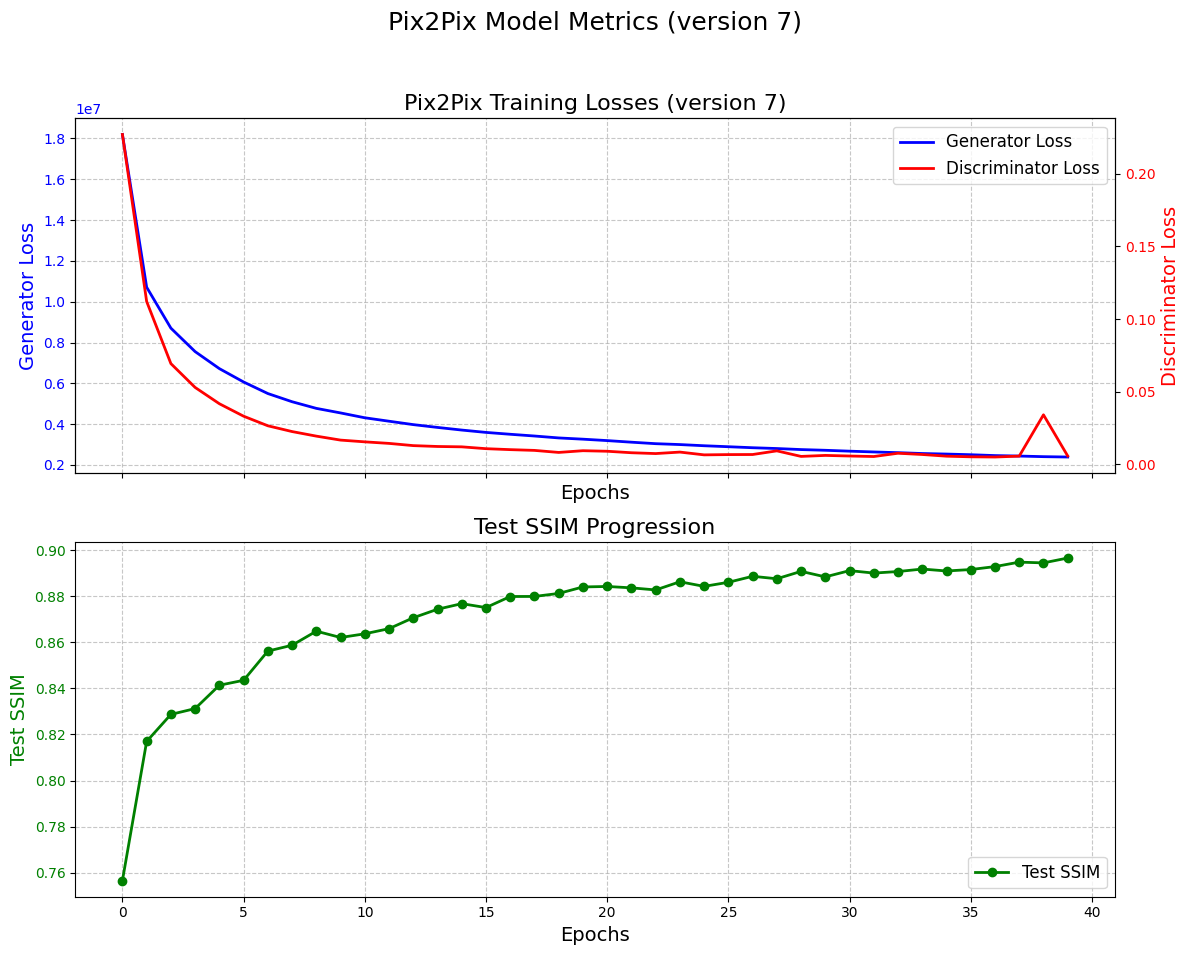

In [13]:
# ================================  TWEAK WITHIN the  TRAINING LOOP ================================

import matplotlib.pyplot as plt
import os

# --- 1. Modify train_step to RETURN the losses ---
@tf.function
def train_step(input_image, target, epoch):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)

        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)

        # Calculate losses
        gen_total_loss = generator_loss(disc_generated_output, gen_output, target, input_image)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_total_loss, generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))
    
    return gen_total_loss, disc_loss

# --- 2. Update the fit function to track and average losses ---
def fit(train_ds, epochs):
    best_ssim = 0.0  # Track the best SSIM
    
    # Initialize lists to store the average loss and metrics per epoch
    history = {'gen_loss': [], 'disc_loss': [], 'test_ssim': []}
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        # Trackers for the current epoch
        epoch_gen_loss = 0.0
        epoch_disc_loss = 0.0
        num_batches = 0
        
        for n, (input_image, target) in train_ds.enumerate():
            # Catch the returned losses
            g_loss, d_loss = train_step(input_image, target, epoch)
            
            # Accumulate them
            epoch_gen_loss += g_loss
            epoch_disc_loss += d_loss
            num_batches += 1
            
            if n % 25 == 0:
                print(f"Batch {n} processed - Gen Loss: {g_loss:.4f}, Disc Loss: {d_loss:.4f}")
        
        # Calculate the average loss for this entire epoch
        avg_gen_loss = (epoch_gen_loss / num_batches).numpy()
        avg_disc_loss = (epoch_disc_loss / num_batches).numpy()
        
        # Evaluate to get exactly current test SSIM mapping
        print("Evaluating Model on Test Dataset...")
        current_ssim = evaluate_model(test_ds, generator)
        
        # Save to history list
        history['gen_loss'].append(avg_gen_loss)
        history['disc_loss'].append(avg_disc_loss)
        history['test_ssim'].append(current_ssim)
        
        print(f"Epoch {epoch+1} Finished -> Avg Gen Loss: {avg_gen_loss:.4f} | Avg Disc Loss: {avg_disc_loss:.4f} | Test SSIM: {current_ssim:.4f}")
        
        # Save the model if the SSIM has improved
        if current_ssim > best_ssim:
            print(f" ==> Epoch {epoch+1}: New best SSIM found: {current_ssim:.4f} (Previous: {best_ssim:.4f}). Saving models...")
            best_ssim = current_ssim
            generator.save('/kaggle/working/MFSR_generator_v7.keras')
            discriminator.save('/kaggle/working/MFSR_discriminator_v7.keras')
            
    # Once all epochs are done, plot the results
    plot_training_history(history)

# --- 3. Add the plotting function ---
def plot_training_history(history):
    fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Plot Generator Loss on the Left Y-Axis
    color = 'blue'
    ax1.set_xlabel('Epochs', fontsize=14)
    ax1.set_ylabel('Generator Loss', color=color, fontsize=14)
    line1 = ax1.plot(history['gen_loss'], label='Generator Loss', color=color, linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Create a secondary Y-Axis for the Discriminator
    ax2 = ax1.twinx()  
    color = 'red'
    ax2.set_ylabel('Discriminator Loss', color=color, fontsize=14)
    line2 = ax2.plot(history['disc_loss'], label='Discriminator Loss', color=color, linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Combine legends
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, fontsize=12, loc='upper right')
    ax1.set_title('Pix2Pix Training Losses (version 7)', fontsize=16)

    # Plot SSIM on the new subplot
    color = 'green'
    ax3.set_xlabel('Epochs', fontsize=14)
    ax3.set_ylabel('Test SSIM', color=color, fontsize=14)
    ax3.plot(history['test_ssim'], label='Test SSIM', color=color, linewidth=2, marker='o')
    ax3.tick_params(axis='y', labelcolor=color)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='lower right', fontsize=12)
    ax3.set_title('Test SSIM Progression', fontsize=16)
    
    fig.suptitle('Pix2Pix Model Metrics (version 7)', fontsize=18)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit suptitle and prevent overlap
    
    save_path = '/kaggle/working/training_losses_and_metrics_chart.png'
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"\nLoss chart successfully saved to: {save_path}")
    
    plt.show()
    plt.close()

# Start training
EPOCHS = 40
fit(train_ds, EPOCHS)

# Step 7.1 Model saving

In [14]:
import os

print("The best generator and discriminator models were automatically saved dynamically")
print("during the training loop to:")
print(" - /kaggle/working/MFSR_generator_v7.keras")
print(" - /kaggle/working/MFSR_discriminator_v7.keras")

# You can omit the manual save block below since training loop handles the 'best' persistence now.
# gen_model_name = 'MFSR_generator_v7.keras'
# disc_model_name = 'MFSR_discriminator_v7.keras'
# gen_save_path = os.path.join(output_dir, gen_model_name)
# generator.save(gen_save_path)
# print(f"Generator saved to: {gen_save_path}")

The best generator and discriminator models were automatically saved dynamically
during the training loop to:
 - /kaggle/working/MFSR_generator_v7.keras
 - /kaggle/working/MFSR_discriminator_v7.keras


# Step 7.2 Loading best model loading (keras format):

In [15]:
import os
import tensorflow as tf

# Define the exact path where your models are saved
model_dir = '/kaggle/working/'
gen_model_name = 'MFSR_generator_v7.keras'
disc_model_name = 'MFSR_discriminator_v7.keras'

gen_load_path = os.path.join(model_dir, gen_model_name)
disc_load_path = os.path.join(model_dir, disc_model_name)

print(f"Loading the Generator model from: {gen_load_path} ...")
# Load the models with compile=False for inference
loaded_generator = tf.keras.models.load_model(gen_load_path, compile=False)

print(f"Loading the Discriminator model from: {disc_load_path} ...")
loaded_discriminator = tf.keras.models.load_model(disc_load_path, compile=False)

print("Models successfully loaded and ready for inference!")

# Optional: Print the model summary just to verify the architecture loaded correctly
# loaded_generator.summary()
# loaded_discriminator.summary()

Loading the Generator model from: /kaggle/working/MFSR_generator_v7.keras ...
Loading the Discriminator model from: /kaggle/working/MFSR_discriminator_v7.keras ...
Models successfully loaded and ready for inference!


# Step 7.3: Evaluating the best Model (Metrics)


In [16]:
def evaluate_model_fixed(test_dataset, generator):
    print("Evaluating model on the test set...")

    total_mae  = 0.0
    total_ssim = 0.0
    total_psnr = 0.0
    num_images = 0  # ← count real images, not batches

    for input_image, target in test_dataset:
        generated_images = generator(input_image, training=False)

        # Normalize from [-1, 1] → [0, 1]
        target_norm    = (target          + 1.0) / 2.0
        generated_norm = (generated_images + 1.0) / 2.0

        # ── MAE ──────────────────────────────────────────────────────────────
        # Reduce over H, W, C → one value per image, shape [batch]
        mae_per_image = tf.reduce_mean(
            tf.abs(target_norm - generated_norm), axis=[1, 2, 3]
        )
        total_mae += tf.reduce_sum(mae_per_image).numpy()

        # ── SSIM ─────────────────────────────────────────────────────────────
        # tf.image.ssim already returns shape [batch] — one score per image
        ssim_per_image = tf.image.ssim(target_norm, generated_norm, max_val=1.0)
        total_ssim += tf.reduce_sum(ssim_per_image).numpy()

        # ── PSNR ─────────────────────────────────────────────────────────────
        # tf.image.psnr already returns shape [batch] — one score per image
        psnr_per_image = tf.image.psnr(target_norm, generated_norm, max_val=1.0)
        total_psnr += tf.reduce_sum(psnr_per_image).numpy()

        # Count the real number of images in this batch (last batch is often smaller)
        num_images += ssim_per_image.shape[0]

    avg_mae  = total_mae  / num_images
    avg_ssim = total_ssim / num_images
    avg_psnr = total_psnr / num_images

    print("-" * 30)
    print(f"Images evaluated : {num_images}")
    print(f"Test MAE  : {avg_mae:.4f}  (Closer to 0 is better)")
    print(f"Test SSIM : {avg_ssim:.4f}  (Closer to 1 is better)")
    print(f"Test PSNR : {avg_psnr:.4f} dB (Higher is better)")
    print("-" * 30)

    # Return scores so the training loop can use them for checkpointing
    return avg_mae, avg_ssim, avg_psnr

In [17]:
# Run the evaluation
evaluate_model(test_ds, loaded_generator)

# Run the evaluation
evaluate_model_fixed(test_ds, loaded_generator)

Evaluating model on the test set...
------------------------------
Test MAE:  0.0190 (Closer to 0 is better)
Test SSIM: 0.8971 (Closer to 1 is better)
Test PSNR: 30.7202 dB (Higher is better)
------------------------------
Evaluating model on the test set...
------------------------------
Images evaluated : 2000
Test MAE  : 0.0193  (Closer to 0 is better)
Test SSIM : 0.8958  (Closer to 1 is better)
Test PSNR : 30.6251 dB (Higher is better)
------------------------------


(np.float32(0.019296074), np.float32(0.8957668), np.float32(30.625092))

# Step 8: Inference and Visualization

> ## Inference

Running inference on a test sample...
Model successfully saved to: /kaggle/working/inference_image_0.png


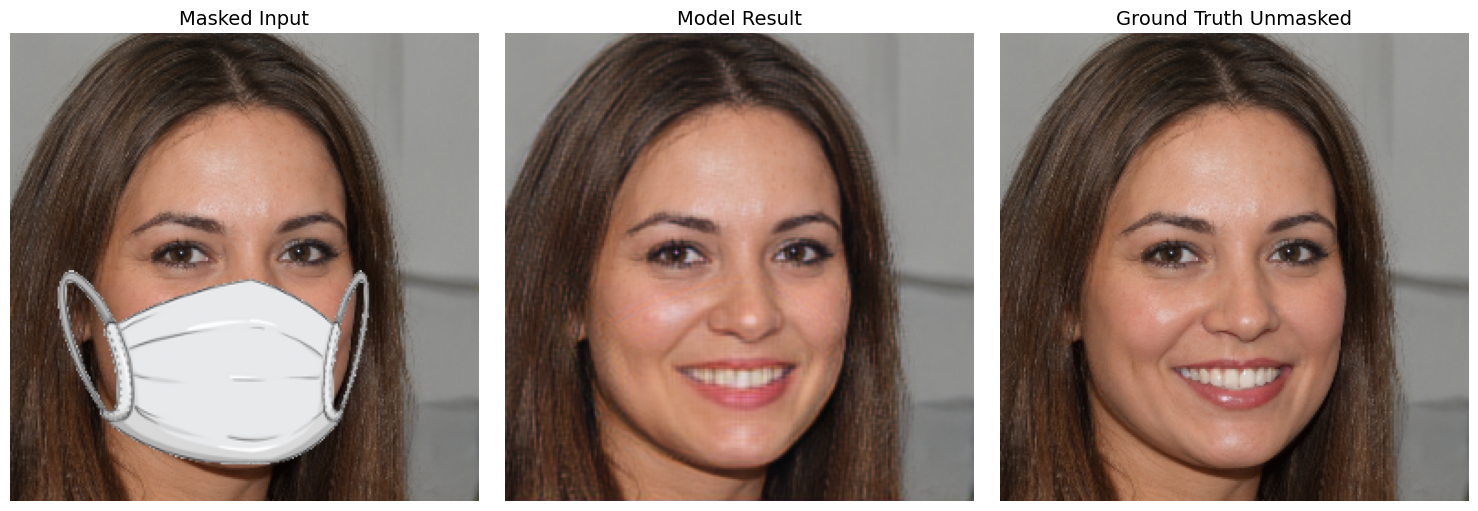

Model successfully saved to: /kaggle/working/inference_image_1.png


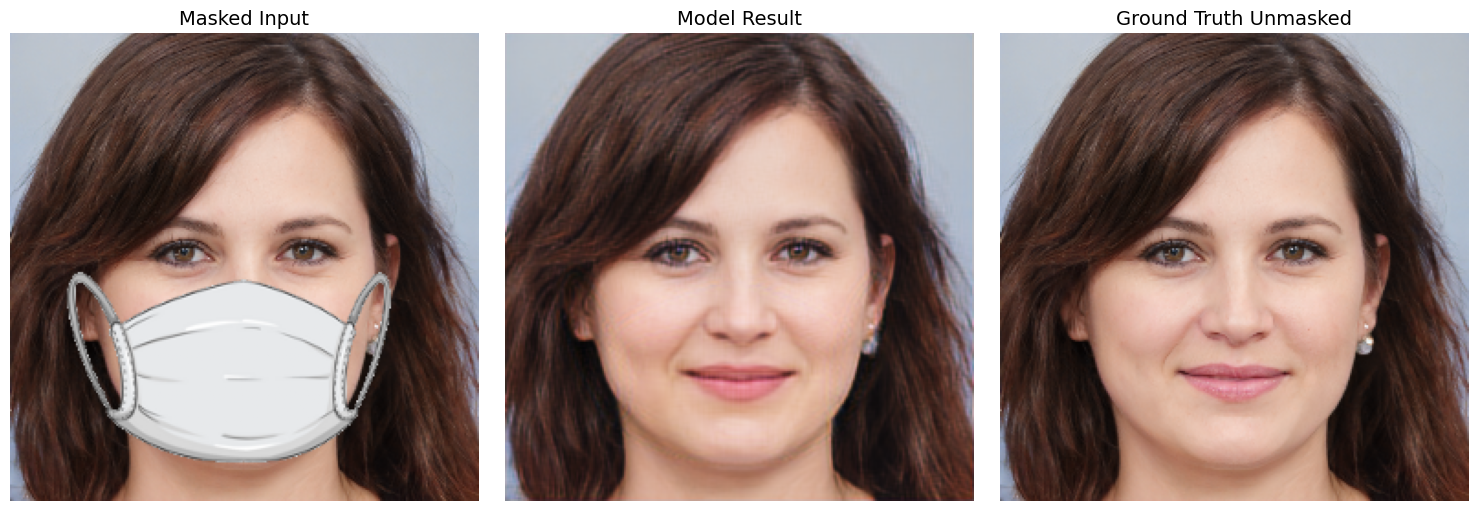

In [18]:
import os
import matplotlib.pyplot as plt

# Define the precise static Kaggle output path from your snippet
output_dir = '/kaggle/working/'

def generate_and_plot_images(model, test_input, target, save_path=None):
    # Generate the unmasked face
    prediction = model(test_input, training=False)
    
    # Take the first image in the batch (index 0)
    display_list = [test_input[0], prediction[0], target[0]]
    titles = ['Masked Input', 'Model Result', 'Ground Truth Unmasked']
    
    plt.figure(figsize=(15, 5))
    
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(titles[i], fontsize=14)
        
        # Denormalize the image from [-1, 1] to [0, 1] for matplotlib
        img = display_list[i] * 0.5 + 0.5
        
        plt.imshow(img)
        plt.axis('off')
        
    plt.tight_layout()

    # MODIFICATION: Saves to the exact path specified, overwriting it if it already exists
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Model successfully saved to: {save_path}")

    plt.show()
        
    plt.close() # Free up memory inside the Kaggle environment

# Extract a single batch from the test dataset and visualize it
print("Running inference on a test sample...")
for i, (example_input, example_target) in enumerate(test_ds.take(2)):
    # Pass the dynamic save_path every time
    dynamic_save_path = os.path.join(output_dir, f'inference_image_{i}.png')
    generate_and_plot_images(generator, example_input, example_target, save_path=dynamic_save_path)

> ## New inference

Running inference on a test sample...
Model successfully saved to: /kaggle/working/new_inference_image_0.png


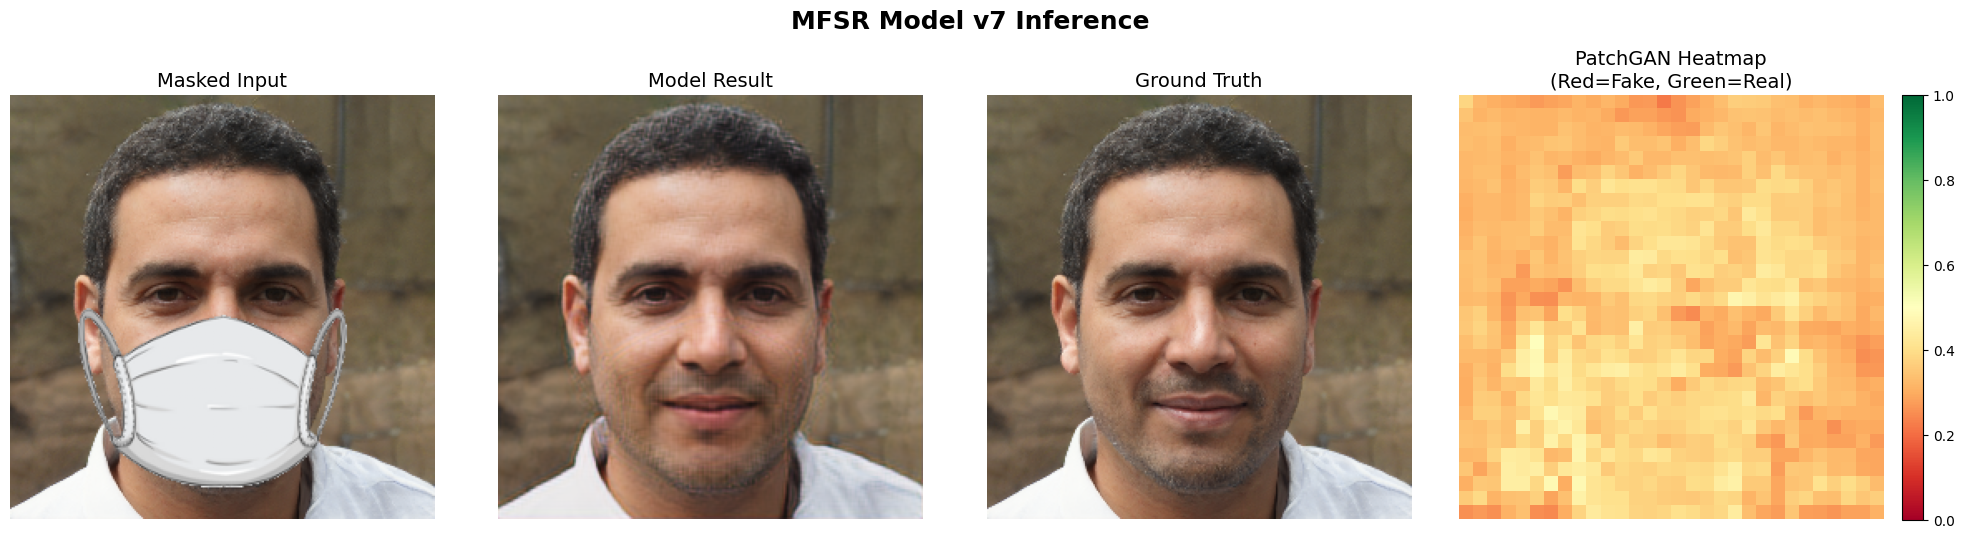

Model successfully saved to: /kaggle/working/new_inference_image_1.png


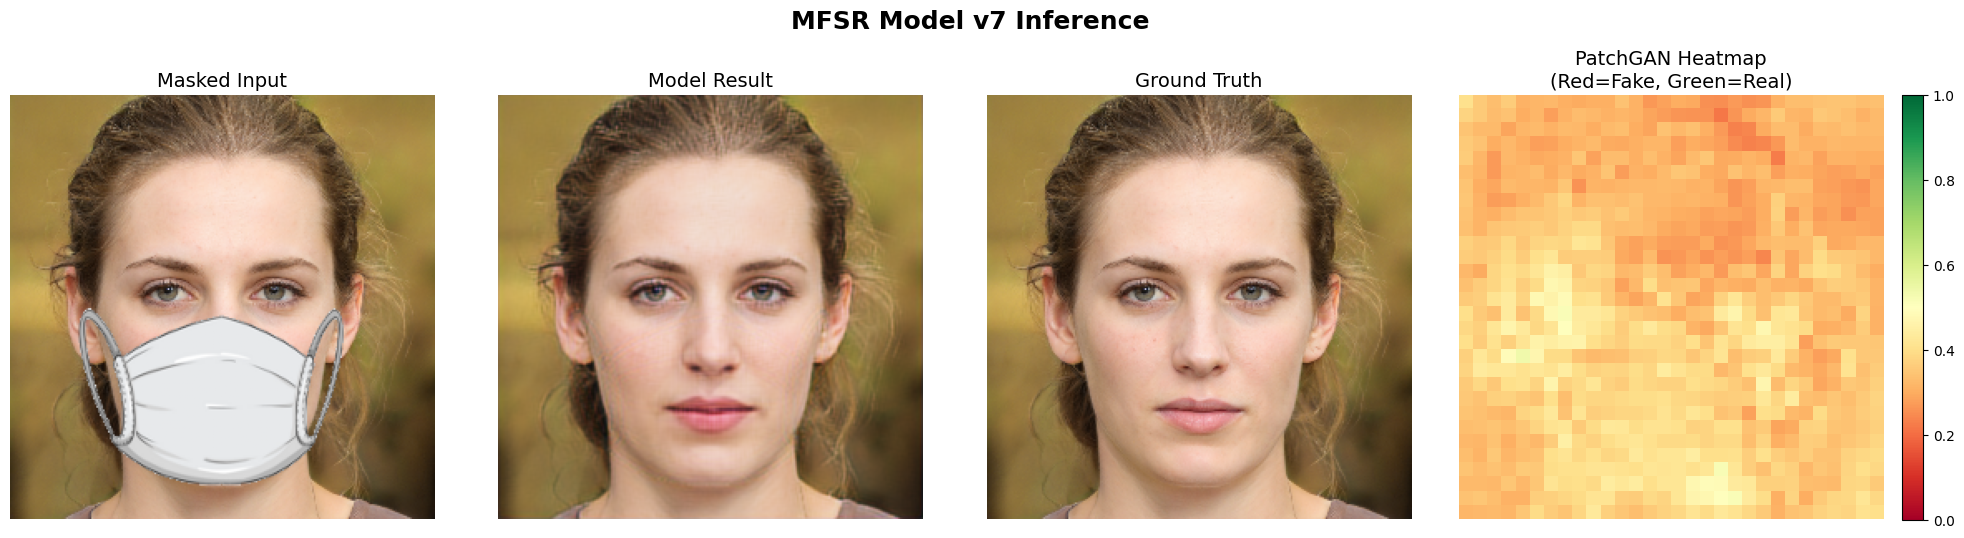

In [19]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

# Define the precise static Kaggle output path from your snippet
output_dir = '/kaggle/working/'
save_name = 'inference_image.png' 
save_path = os.path.join(output_dir, save_name)

# UPGRADE: Added discriminator to the function parameters
def generate_and_plot_images(generator, discriminator, test_input, target, save_path=None, fig_title=None):
    # 1. Generate the unmasked face
    prediction = generator(test_input, training=False)
    
    # 2. Ask the discriminator to evaluate the GENERATED image
    # Note: PatchGAN takes [condition_image, target_image]
    disc_logits = discriminator([test_input, prediction], training=False)
    
    # 3. Convert raw logits to probabilities (0.0 = Fake, 1.0 = Real)

    # --------------------------------------------------------------------------------------
    # for cross entropy loss (or hinge loss), we would use sigmoid to convert logits to 0-1 probabilities
    # heatmap_probs = tf.sigmoid(disc_logits[0]) 
    # --------------------------------------------------------------------------------------
    # --------------------------------------------------------------------------------------
    # for LSGAN loss, the discriminator outputs are already in the range of 0 to 1, so we directly clip them to ensure they are valid probabilities
    # --------------------------------------------------------------------------------------
    heatmap_probs = tf.clip_by_value(disc_logits[0], clip_value_min=0.0, clip_value_max=1.0)

    heatmap_2d = tf.squeeze(heatmap_probs) # Remove the channel dimension so it becomes a 30x30 2D array
    
    # Take the first image in the batch (index 0)
    display_list = [test_input[0], prediction[0], target[0]]
    titles = ['Masked Input', 'Model Result', 'Ground Truth', 'PatchGAN Heatmap\n(Red=Fake, Green=Real)']
    
    # Increased width from 15 to 20 to comfortably fit 4 subplots
    plt.figure(figsize=(20, 5))
    
    # Add a main title for the entire figure if provided
    if fig_title:
        plt.suptitle(fig_title, fontsize=18, fontweight='bold', y=1.05)
    
    # Plot the 3 standard images
    for i in range(3):
        plt.subplot(1, 4, i+1)
        plt.title(titles[i], fontsize=14)
        
        # Denormalize the image from [-1, 1] to [0, 1] for matplotlib
        img = display_list[i] * 0.5 + 0.5
        
        plt.imshow(img)
        plt.axis('off')
        
    # Plot the 4th image: The Discriminator Heatmap
    plt.subplot(1, 4, 4)
    plt.title(titles[3], fontsize=14)
    # RdYlGn colormap forces 0 to be Red and 1 to be Green
    im = plt.imshow(heatmap_2d, cmap='RdYlGn', vmin=0, vmax=1)
    plt.axis('off')
    # Add a colorbar next to the heatmap to show the scale
    plt.colorbar(im, fraction=0.046, pad=0.04)
        
    plt.tight_layout()
    
    # Save the combined plot
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Model successfully saved to: {save_path}")

    plt.show()
        
    plt.close() # Free up memory inside the Kaggle environment


# Extract a single batch from the test dataset and visualize it
print("Running inference on a test sample...")
for i, (example_input, example_target) in enumerate(test_ds.take(2)):
    # Pass BOTH the generator and discriminator into the function, along with a title
    dynamic_save_path = os.path.join(output_dir, f'new_inference_image_{i}.png')
    generate_and_plot_images(loaded_generator, loaded_discriminator, example_input, example_target, save_path=dynamic_save_path, fig_title="MFSR Model v7 Inference")

# **Project Documentation: MFSR model (Version 7)**

This notebook implements an **Image-to-Image Translation** model to reconstruct facial features hidden behind masks. 

##  Architecture Pivot
This Version 7 utilizes the **Pix2Pix (Conditional GAN)** architecture. This allows us to map a specific input image (masked) to a specific output image (unmasked).
* **Generator:** An upgraded **U-Net** architecture with skip connections to preserve spatial details. It uses bilinear `UpSampling2D` instead of standard transpose convolutions in the decoder layer to avoid overlapping checkerboard artifacts.
* **Discriminator:** A **PatchGAN** that evaluates pairs of images (Input + Target/Generated) to determine realism on a local patch level.

## Pipeline Steps Completed

1. **Data Ingestion & Preprocessing (`tf.data`)**
   * Configured paths to the Kaggle dataset mount points.
   * Solved filename mismatches using `tf.strings.regex_replace` to safely pair `with-mask-default-mask-seed.png` inputs with `seed.png` targets.
   * Standardized images to `256x256` and normalized pixels to the `[-1, 1]` range.
   * Implemented a reliable 80/20 Train/Test split via proper dataset shuffling before batching.

2. **Custom Training Loop**
   * Utilized `tf.GradientTape` for manual gradient application.
   * **Loss Functions:** Replaced standard Binary Crossentropy with **MSE (Least Squares GAN / LSGAN loss)** for improved stability and smoother generation. Combined this with **Weighted L1 Loss** (dynamically focuses more heavily inside the missing face region) and **Perceptual Loss** (uses a pre-trained VGG19 `block4_conv2` layer scaled by a factor of 10).
   * **Target Smoothing:** Implemented **One-Sided Label Smoothing** in the discriminator loss, scaling the target for real images down from 1.0 to 0.9. This prevents the discriminator from becoming overconfident and destabilizing the generator.
   * **Optimizer Tuning:** To prevent the Discriminator from overpowering the Generator, its learning rate was slowed down by 20x compared to the Generator (`2e-5` for the Discriminator vs `2e-4` for the Generator) **TTUR (Asymmetric Learning Rates)**.
   * **choosing best model** by evalutin on test set every epoch
   * **Tracking:** Implemented history lists to record and plot metrics (Generator Loss vs. Discriminator Loss) with a dual-axis chart. + tracskin off ssim metric

3. **Evaluation & Inference**
   * Integrated **MAE (Mean Absolute Error)**, **SSIM (Structural Similarity Index)**, and **PSNR (Peak Signal-to-Noise Ratio)** metrics to quantitatively evaluate the Generator on unseen test data.
   * Built custom inference visualization, denormalizing images from `[-1, 1]` back to `[0, 1]` to safely display the Input, Prediction, and Ground Truth side-by-side.
   * Fixed PatchGAN heatmap generation to properly utilize `tf.clip_by_value()` for probability conversion according to the new LSGAN logic.

4. **Model Export**
   * Saved both the trained **Generator** (as `MFSR_generator_v7.keras`) and the **Discriminator** (as `MFSR_discriminator_v7.keras`) in the `/kaggle/working/` directory. This allows for both advanced inference (e.g., generating heatmaps) and easily resuming training in the future.

---
*End of Version 7 Pipeline.*

In [20]:
print ("version 7 done")

version 7 done
